C:\Users\AUSTCSE4090\anaconda3\envs\py310\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train images: 15
Test images : 5
✅ STARE RAM-safe datasets ready
Total patches: 100


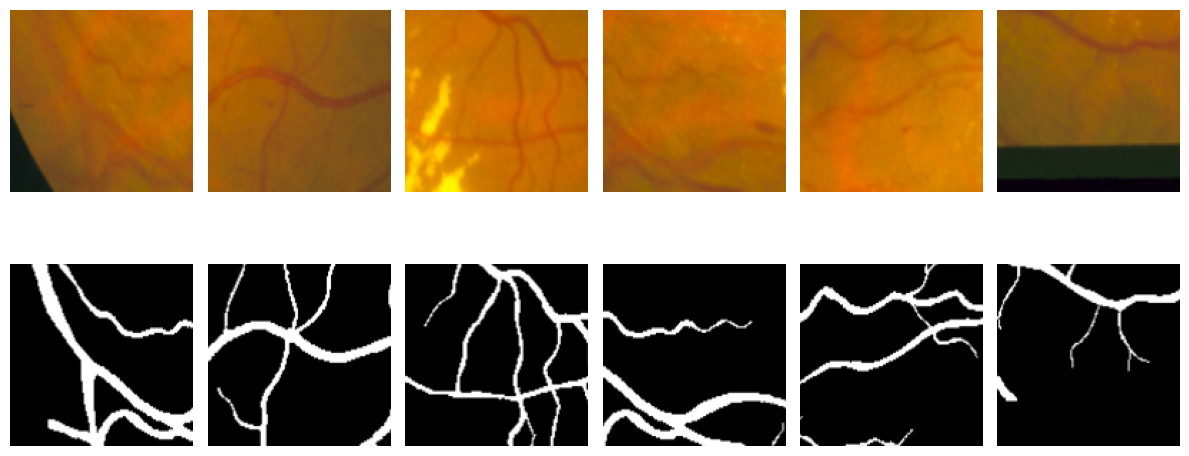

In [1]:
# ================= IMPORTS =================
import os
import cv2
import numpy as np
import tensorflow as tf
import albumentations as A
import matplotlib.pyplot as plt
import random
import gzip
import shutil

# ================= TF SAFETY =================
tf.keras.backend.clear_session()

tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

# ================= PATHS =================
IMAGE_DIR = r"C:\Users\AUSTCSE4090\Desktop\STARE\stare\stare-images"
MASK_DIR  = r"C:\Users\AUSTCSE4090\Desktop\STARE\stare\labels-ah"

# ================= CONSTANTS =================
RESIZE_SIZE = 704
IMG_SIZE    = 128
OVERLAP     = 0.5
BATCH_SIZE  = 8          # SAFE
SHUFFLE_BUF = 128

# ================= AUGMENTATION =================
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
])

# ================= DECOMPRESSION =================
def decompress_ppm_gz(input_path, output_path):
    with gzip.open(input_path, 'rb') as f_in:
        with open(output_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

def decompress_all_files(image_dir, mask_dir):
    for dir_path in [image_dir, mask_dir]:
        for f in os.listdir(dir_path):
            if f.endswith(".ppm.gz"):
                inp = os.path.join(dir_path, f)
                out = os.path.join(dir_path, f.replace(".gz", ""))
                print("Decompressing:", f)
                decompress_ppm_gz(inp, out)
                os.remove(inp)

# Run once
if not any(f.endswith(".ppm") for f in os.listdir(IMAGE_DIR)):
    decompress_all_files(IMAGE_DIR, MASK_DIR)

# ================= UTIL =================
def is_valid_patch(mask, threshold=0.01):
    return np.count_nonzero(mask) / mask.size > threshold

def load_image_mask_paths(image_dir, mask_dir):
    images = sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.endswith(".ppm")
    ])
    masks = sorted([
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.endswith(".ppm")
    ])
    return images, masks

# ================= PATCH STREAM =================
def extract_patches_stream(img, mask, patch_size, overlap, skip_empty):
    stride = int(patch_size * (1 - overlap))
    H, W = img.shape[:2]

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            p_img  = img[y:y+patch_size, x:x+patch_size]
            p_mask = mask[y:y+patch_size, x:x+patch_size]

            if skip_empty and not is_valid_patch(p_mask):
                continue

            yield p_img, p_mask

# ================= GENERATOR =================
def generator(image_paths, mask_paths, augment=True, skip_empty=True):
    for img_path, mask_path in zip(image_paths, mask_paths):

        img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img  = cv2.resize(img,  (RESIZE_SIZE, RESIZE_SIZE))
        mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

        for p_img, p_mask in extract_patches_stream(
            img, mask, IMG_SIZE, OVERLAP, skip_empty
        ):

            if augment:
                data = augmenter(image=p_img, mask=p_mask)
                p_img, p_mask = data["image"], data["mask"]

            p_img  = p_img.astype(np.float32) / 255.0
            p_mask = np.expand_dims(
                p_mask.astype(np.float32) / 255.0, axis=-1
            )

            yield p_img, p_mask

# ================= LOAD DATA =================
all_images, all_masks = load_image_mask_paths(IMAGE_DIR, MASK_DIR)

train_images = all_images[:15]
train_masks  = all_masks[:15]

test_images  = all_images[15:20]
test_masks   = all_masks[15:20]

print("Train images:", len(train_images))
print("Test images :", len(test_images))

# ================= TF.DATA =================
output_signature = (
    tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
    tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32),
)

train_ds = tf.data.Dataset.from_generator(
    lambda: generator(train_images, train_masks, augment=True, skip_empty=True),
    output_signature=output_signature
).shuffle(SHUFFLE_BUF)\
 .batch(BATCH_SIZE)\
 .prefetch(1)

test_ds = tf.data.Dataset.from_generator(
    lambda: generator(test_images, test_masks, augment=False, skip_empty=False),
    output_signature=output_signature
).batch(BATCH_SIZE)

print("✅ STARE RAM-safe datasets ready")

# ================= VISUALIZATION (SAFE) =================
def visualize_patches(img_path, mask_path, num_samples=6):
    img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    img  = cv2.resize(img,  (RESIZE_SIZE, RESIZE_SIZE))
    mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

    patches = list(
        extract_patches_stream(img, mask, IMG_SIZE, OVERLAP, skip_empty=False)
    )

    print("Total patches:", len(patches))

    indices = random.sample(range(len(patches)), min(num_samples, len(patches)))

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices):
        p_img, p_mask = patches[idx]

        plt.subplot(2, num_samples, i+1)
        plt.imshow(p_img)
        plt.axis("off")

        plt.subplot(2, num_samples, i+1+num_samples)
        plt.imshow(p_mask, cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example
visualize_patches(train_images[0], train_masks[0])

In [2]:
# ================= LOAD PATHS =================
all_images, all_masks = load_image_mask_paths(IMAGE_DIR, MASK_DIR)

# Debugging: Check if the images and masks were loaded correctly
print(f"Total images: {len(all_images)}")
print(f"Total masks: {len(all_masks)}")


Total images: 20
Total masks: 20


In [3]:
import tensorflow as tf
from tensorflow.keras import backend as K

def confusion_elements(y_true, y_pred):
    """Helper to calculate TP, TN, FP, FN"""
    y_pred = K.round(y_pred)
    y_true = K.round(y_true)
    TP = K.sum(y_true * y_pred)
    TN = K.sum((1 - y_true) * (1 - y_pred))
    FP = K.sum((1 - y_true) * y_pred)
    FN = K.sum(y_true * (1 - y_pred))
    return TP, TN, FP, FN

# Sensitivity (Recall)
def sensitivity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FN + K.epsilon())

# Specificity
def specificity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TN / (TN + FP + K.epsilon())

# Accuracy
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN + K.epsilon())

# Precision
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FP + K.epsilon())

# F1-score
def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = sensitivity(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec + K.epsilon()))

# AUC (use Keras built-in metric)
auc = tf.keras.metrics.AUC(name='auc')


import tensorflow as tf
import tensorflow.keras.backend as K

smooth = 1e-6

def iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(K.round(y_pred), tf.float32)  # Round to binary
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(K.round(y_pred))  # Round predictions to binary
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [4]:
def get_kernel():
    """
    See https://setosa.io/ev/image-kernels/
    """

    k1 = np.array([[0.0625, 0.125, 0.0625],
                   [0.125,  0.25, 0.125],
                   [0.0625, 0.125, 0.0625]])

    # Sharpening Spatial Kernel, used in paper
    k2 = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])

    k3 = np.array([[0, -1, 0],
                   [-1,  5, -1],
                   [0, -1, 0]])

    return k1, k2, k3


def build_sharp_blocks(layer):
    """
    Sharp Blocks
    """
    # Get number of channels in the feature
    in_channels = layer.shape[-1]
    # Get kernel
    _, w, _ = get_kernel()
    # Change dimension
    w = np.expand_dims(w, axis=-1)
    # Repeat filter by in_channels times to get (H, W, in_channels)
    w = np.repeat(w, in_channels, axis=-1)
    # Expand dimension
    w = np.expand_dims(w, axis=-1)
    return w

In [5]:
from tensorflow.keras import Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, concatenate, DepthwiseConv2D, Conv2DTranspose
from tensorflow.keras.models import Model

def SharpUNet(img_size, num_classes):
    """
    Sharp U-Net model with sharp blocks in skip connections
    """
    kernel_size = 3  # Kernel size for sharp blocks

    inputs = Input(img_size)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv5)

    # Skip connection 1
    W1 = build_sharp_blocks(conv4)  # Assuming build_sharp_blocks function is defined elsewhere
    sb1 = DepthwiseConv2D(kernel_size, use_bias=False, padding='same')
    conv4 = sb1(conv4)
    sb1.set_weights([W1])
    sb1.trainable = False

    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv6)

    # Skip connection 2
    W2 = build_sharp_blocks(conv3)  # Assuming build_sharp_blocks function is defined elsewhere
    sb2 = DepthwiseConv2D(kernel_size, use_bias=False, padding='same')
    conv3 = sb2(conv3)
    sb2.set_weights([W2])
    sb2.trainable = False

    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv7)

    # Skip connection 3
    W3 = build_sharp_blocks(conv2)  # Assuming build_sharp_blocks function is defined elsewhere
    sb3 = DepthwiseConv2D(kernel_size, use_bias=False, padding='same')
    conv2 = sb3(conv2)
    sb3.set_weights([W3])
    sb3.trainable = False

    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv8)

    # Skip connection 4
    W4 = build_sharp_blocks(conv1)  # Assuming build_sharp_blocks function is defined elsewhere
    sb4 = DepthwiseConv2D(kernel_size, use_bias=False, padding='same')
    conv1 = sb4(conv1)
    sb4.set_weights([W4])
    sb4.trainable = False

    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)

    # Final output layer for multi-class segmentation (using 'sigmoid' for binary classification)
    conv10 = Conv2D(num_classes, (1, 1), activation='sigmoid')(conv9)

    model = Model(inputs=[inputs], outputs=[conv10])

    return model

# Model compilation example:
model = SharpUNet((128, 128, 3), 1)  # Binary segmentation example
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 32  896         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 128, 128, 32  9248        ['conv2d[0][0]']                 
                                )                                                             

In [6]:
import tensorflow as tf
from tensorflow.keras import backend as K

# ----------------------------------
# Tversky Index
# ----------------------------------
def tversky(y_true, y_pred, alpha=0.7, beta=0.3):
    # numerical stability
    y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)

    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    

    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)

    return (true_pos + 1e-6) / (
        true_pos + alpha * false_neg + beta * false_pos + 1e-6
    )


# ----------------------------------
# Focal Tversky Loss
# ----------------------------------
def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    tv = tversky(y_true, y_pred)
    return K.pow((1 - tv), gamma)


# ----------------------------------
# Hybrid Loss (Recommended)
# ----------------------------------
def hybrid_loss(y_true, y_pred):
    ft = focal_tversky_loss(y_true, y_pred)
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return 0.7 * ft + 0.3 * bce


In [7]:
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.optimizers import Adam


# Define Adam optimizer with an initial learning rate
initial_lr = 1e-4
optimizer = Adam(learning_rate=initial_lr)


def lr_schedule(epoch, lr):
    if epoch < 5:  # Warmup phase
        return lr * 1.5  # Increase LR to stabilize training
    elif epoch < 30:
        return lr * 0.98  # Gradual decay
    else:
        return lr * 0.95  # Final stabilization

lr_scheduler = LearningRateScheduler(lr_schedule)

In [8]:
from tensorflow.keras.losses import BinaryCrossentropy
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True),
    lr_scheduler
    #tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]



# Compile the model
model.compile(
    optimizer=optimizer,
    loss= hybrid_loss,  # Use BCE loss for binary segmentation
    metrics=[sensitivity, specificity, accuracy, f1_score, auc,dice_coef,iou]  # Your custom metrics
)


# Fit the model
history = model.fit(
    train_ds,
    #validation_data=test_ds,
     # optional if dataset is finite
    epochs=80,
)


Epoch 1/80
181/181 [==============================] - 8s 16ms/step - loss: 0.6454 - sensitivity: 0.2130 - specificity: 0.9763 - accuracy: 0.9086 - f1_score: 0.1988 - auc: 0.7059 - dice_coef: 0.1973 - iou: 0.1417
Epoch 2/80
181/181 [==============================] - 2s 12ms/step - loss: 0.3838 - sensitivity: 0.7266 - specificity: 0.9515 - accuracy: 0.9316 - f1_score: 0.6575 - auc: 0.9143 - dice_coef: 0.6517 - iou: 0.4930
Epoch 3/80
181/181 [==============================] - 2s 13ms/step - loss: 0.3518 - sensitivity: 0.7627 - specificity: 0.9568 - accuracy: 0.9395 - f1_score: 0.6953 - auc: 0.9256 - dice_coef: 0.6886 - iou: 0.5315
Epoch 4/80
181/181 [==============================] - 2s 13ms/step - loss: 0.3329 - sensitivity: 0.7857 - specificity: 0.9586 - accuracy: 0.9433 - f1_score: 0.7133 - auc: 0.9323 - dice_coef: 0.7059 - iou: 0.5518
Epoch 5/80
181/181 [==============================] - 2s 13ms/step - loss: 0.3164 - sensitivity: 0.8018 - specificity: 0.9612 - accuracy: 0.9471 - f1_sc

Mean Dice        : 0.7915
Mean IoU         : 0.6580
Mean Accuracy    : 0.9720
Mean F1 Score    : 0.7915
Mean Sensitivity : 0.7863
Mean Specificity : 0.9854


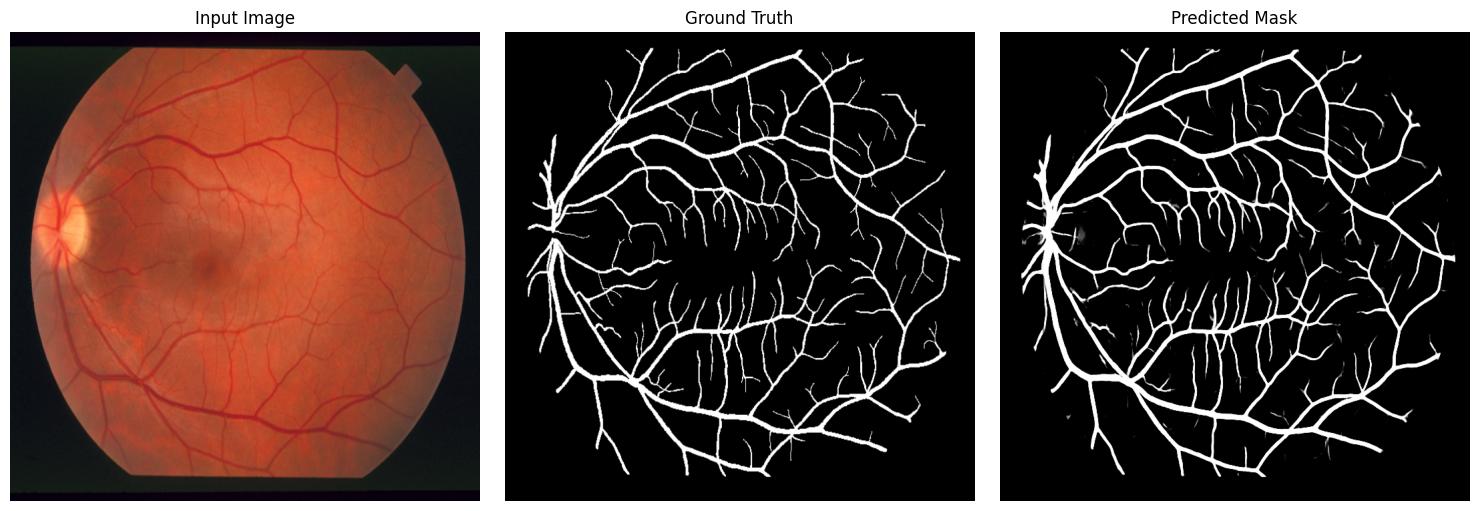

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

#================= CONSTANTS =================

RESIZE_SIZE = 704  # Full image resize
IMG_SIZE    = 128   # Patch size
OVERLAP     = 0.5   # 50% overlap
THRESHOLD   = 0.5   # Binarization threshold
BATCH_SIZE  = 16    # Mini-batch size for patch prediction

#================= PATCH FUNCTIONS =================

def extract_patches(img, patch_size=IMG_SIZE, overlap=OVERLAP):
    stride = int(patch_size * (1 - overlap))
    H, W = img.shape[:2]
    patches = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patches.append(img[y:y+patch_size, x:x+patch_size])
    return patches

def stitch_patches(patches, image_size=RESIZE_SIZE, patch_size=IMG_SIZE, overlap=OVERLAP):
    stride = int(patch_size * (1 - overlap))
    stitched_mask = np.zeros((image_size, image_size), dtype=np.float32)
    count_mask = np.zeros((image_size, image_size), dtype=np.float32)

    idx = 0  
    for y in range(0, image_size - patch_size + 1, stride):  
        for x in range(0, image_size - patch_size + 1, stride):  
            stitched_mask[y:y+patch_size, x:x+patch_size] += patches[idx]  
            count_mask[y:y+patch_size, x:x+patch_size] += 1  
            idx += 1  

    stitched_mask /= count_mask  
    return np.clip(stitched_mask, 0, 1)

#================= FULL IMAGE PREDICTION =================

def predict_full_image(model, img_path, batch_size=BATCH_SIZE):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))

    patches = extract_patches(img)  
    pred_patches = []  

    # Predict in mini-batches  
    for i in range(0, len(patches), batch_size):  
        batch = np.array([p.astype(np.float32)/255.0 for p in patches[i:i+batch_size]])  
        preds = model.predict(batch, verbose=0)  
        pred_patches.extend([p[:, :, 0] for p in preds])  # remove channel dim  

    full_mask = stitch_patches(pred_patches)  
    return img, full_mask

#================= EVALUATION FUNCTION =================

def evaluate_model(model, image_paths, mask_paths):
    dice_list, iou_list, acc_list, f1_list, sens_list, spec_list = [], [], [], [], [], []

    for img_path, mask_path in zip(image_paths, mask_paths):  
        img, pred_mask = predict_full_image(model, img_path)  

        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  
        gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0  

        pred_bin = (pred_mask >= THRESHOLD).astype(np.float32)  
        gt_bin   = (gt_mask >= 0.5).astype(np.float32)  

        intersection = np.sum(pred_bin * gt_bin)  
        union = np.sum(pred_bin) + np.sum(gt_bin) - intersection  
        dice = (2 * intersection) / (np.sum(pred_bin) + np.sum(gt_bin) + 1e-7)  
        iou  = intersection / (union + 1e-7)  
        acc  = accuracy_score(gt_bin.flatten(), pred_bin.flatten())  
        f1   = f1_score(gt_bin.flatten(), pred_bin.flatten())  
        sens = recall_score(gt_bin.flatten(), pred_bin.flatten())  
        spec = (np.sum((1 - gt_bin) * (1 - pred_bin)) / np.sum(1 - gt_bin))  

        dice_list.append(dice)  
        iou_list.append(iou)  
        acc_list.append(acc)  
        f1_list.append(f1)  
        sens_list.append(sens)  
        spec_list.append(spec)  

    print(f"Mean Dice        : {np.mean(dice_list):.4f}")  
    print(f"Mean IoU         : {np.mean(iou_list):.4f}")  
    print(f"Mean Accuracy    : {np.mean(acc_list):.4f}")  
    print(f"Mean F1 Score    : {np.mean(f1_list):.4f}")  
    print(f"Mean Sensitivity : {np.mean(sens_list):.4f}")  
    print(f"Mean Specificity : {np.mean(spec_list):.4f}")

#================= VISUALIZATION =================

def visualize_prediction(model, img_path, mask_path):
    img, pred_mask = predict_full_image(model, img_path)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

    plt.figure(figsize=(15,5))  
    plt.subplot(1,3,1)  
    plt.imshow(img)  
    plt.title("Input Image")  
    plt.axis("off")  

    plt.subplot(1,3,2)  
    plt.imshow(gt_mask, cmap="gray")  
    plt.title("Ground Truth")  
    plt.axis("off")  

    plt.subplot(1,3,3)  
    plt.imshow(pred_mask, cmap="gray")  
    plt.title("Predicted Mask")  
    plt.axis("off")  

    plt.tight_layout()  
    plt.show()

#================= USAGE =================

# Evaluate all test images
evaluate_model(model, test_images, test_masks)

# Visualize first test image
visualize_prediction(model, test_images[1], test_masks[1])


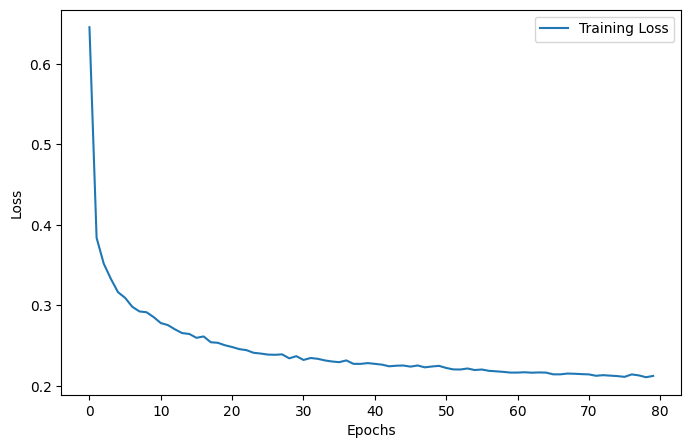

In [10]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Metrics for Image 1: Sens: 0.792, Spec: 0.982, Acc: 0.962, F1: 0.811, Dice: 0.811, IoU: 0.683


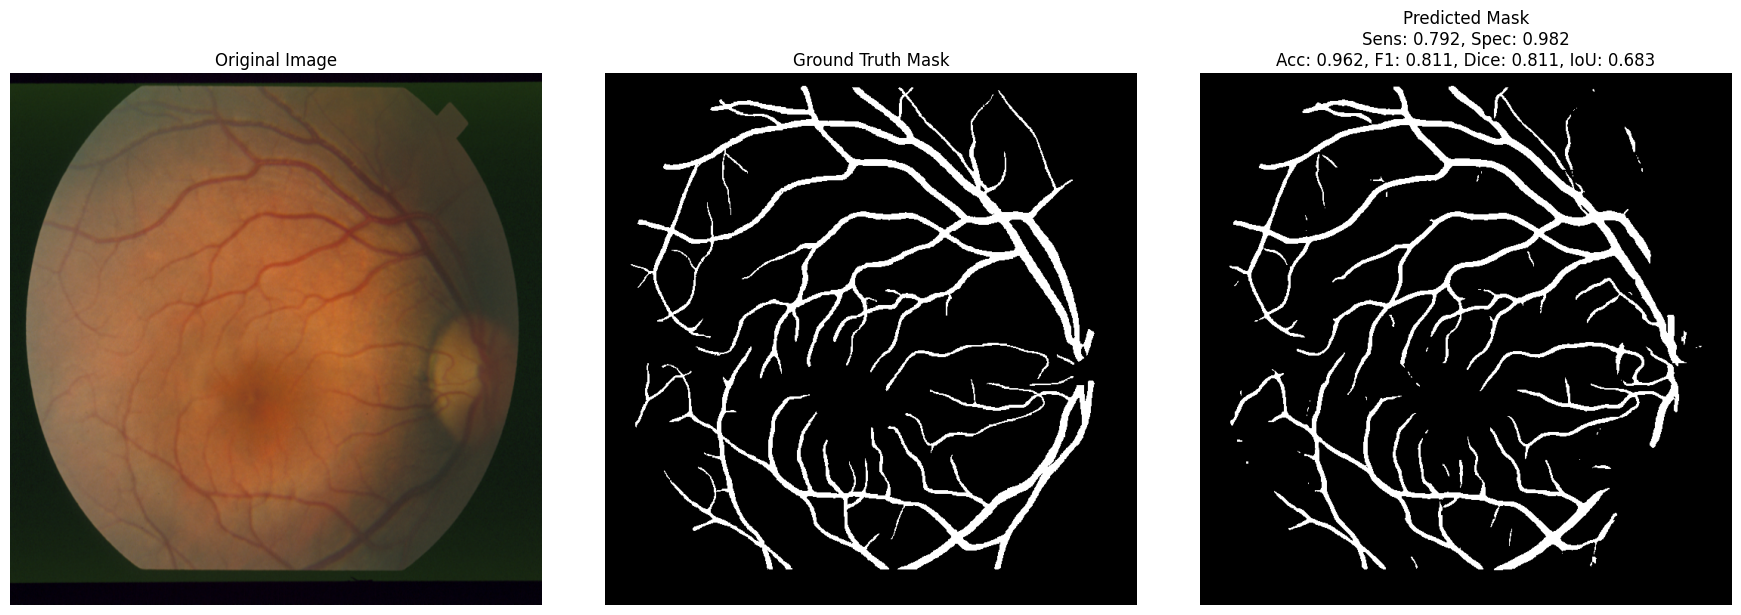

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet original image\original_image_1.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet predicted_mask\predicted_mask_1.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet_ground_truth_mask\ground_truth_mask_1.png
Metrics for Image 1 written to CSV.
Metrics for Image 2: Sens: 0.910, Spec: 0.977, Acc: 0.971, F1: 0.849, Dice: 0.849, IoU: 0.737


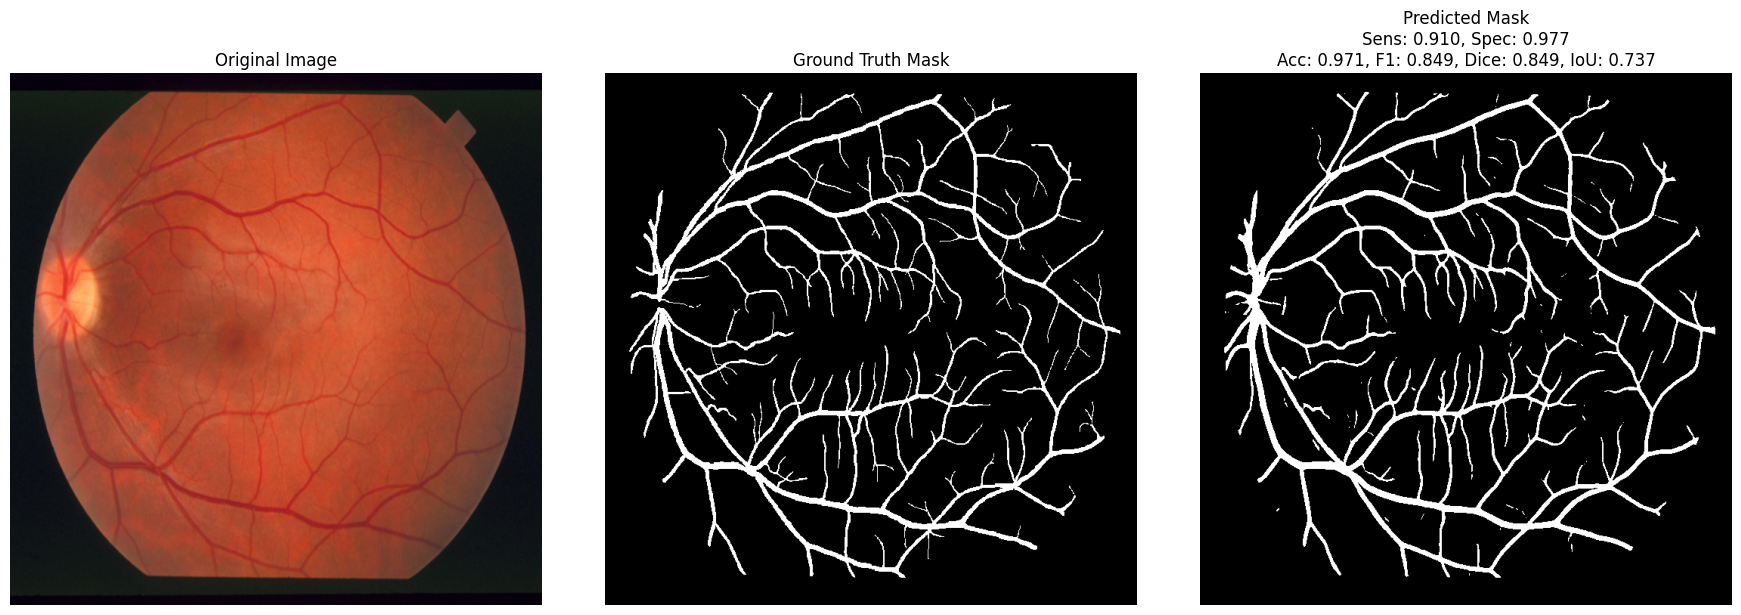

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet original image\original_image_2.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet predicted_mask\predicted_mask_2.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet_ground_truth_mask\ground_truth_mask_2.png
Metrics for Image 2 written to CSV.
Metrics for Image 3: Sens: 0.835, Spec: 0.989, Acc: 0.981, F1: 0.818, Dice: 0.818, IoU: 0.692


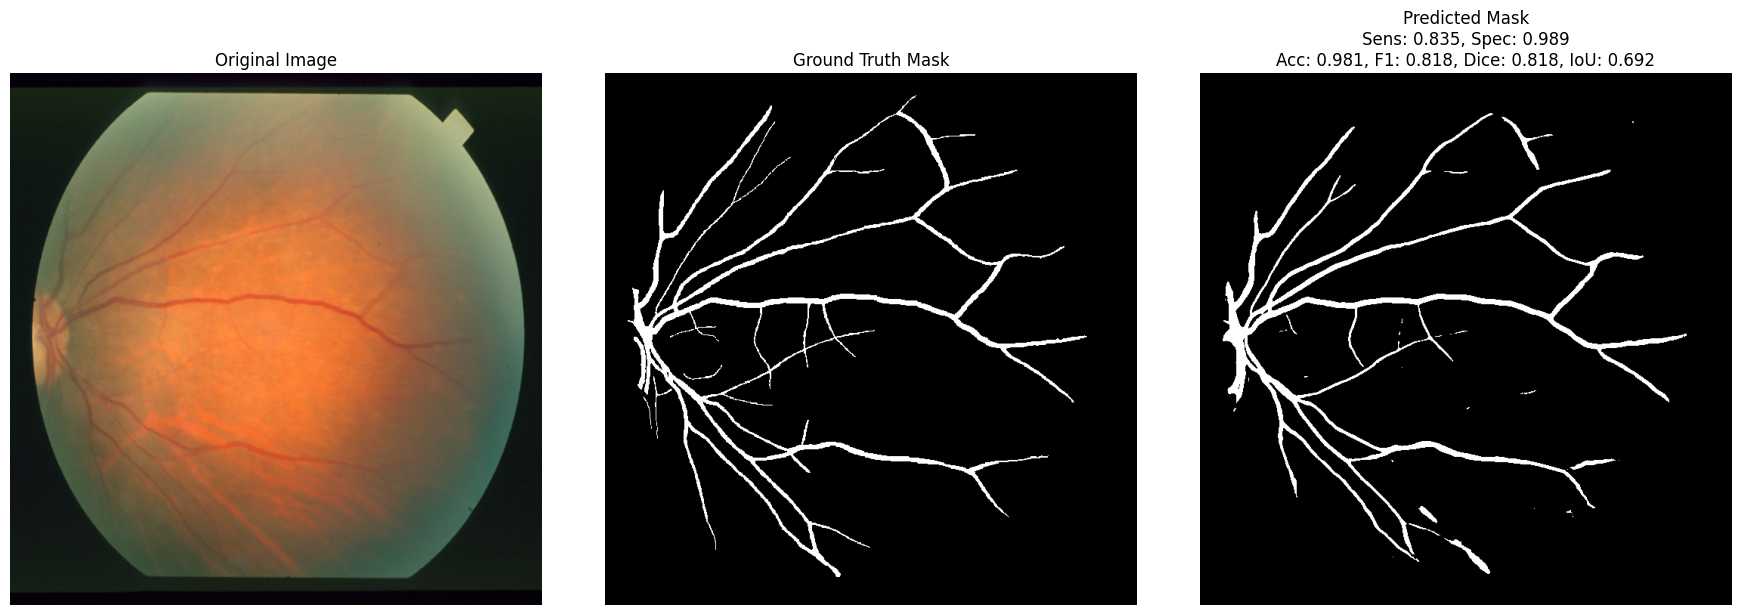

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet original image\original_image_3.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet predicted_mask\predicted_mask_3.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet_ground_truth_mask\ground_truth_mask_3.png
Metrics for Image 3 written to CSV.
Metrics for Image 4: Sens: 0.773, Spec: 0.991, Acc: 0.982, F1: 0.784, Dice: 0.784, IoU: 0.645


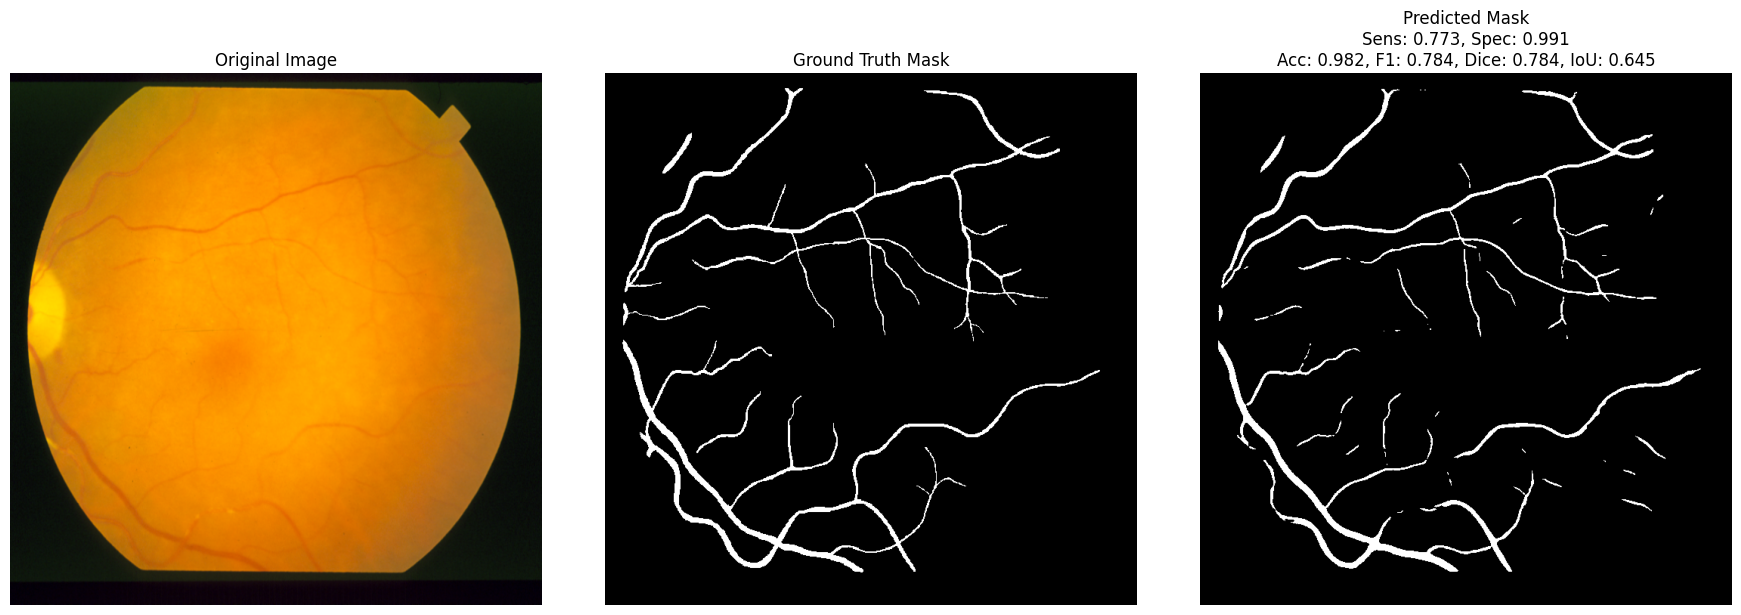

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet original image\original_image_4.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet predicted_mask\predicted_mask_4.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet_ground_truth_mask\ground_truth_mask_4.png
Metrics for Image 4 written to CSV.
Metrics for Image 5: Sens: 0.622, Spec: 0.988, Acc: 0.964, F1: 0.695, Dice: 0.695, IoU: 0.533


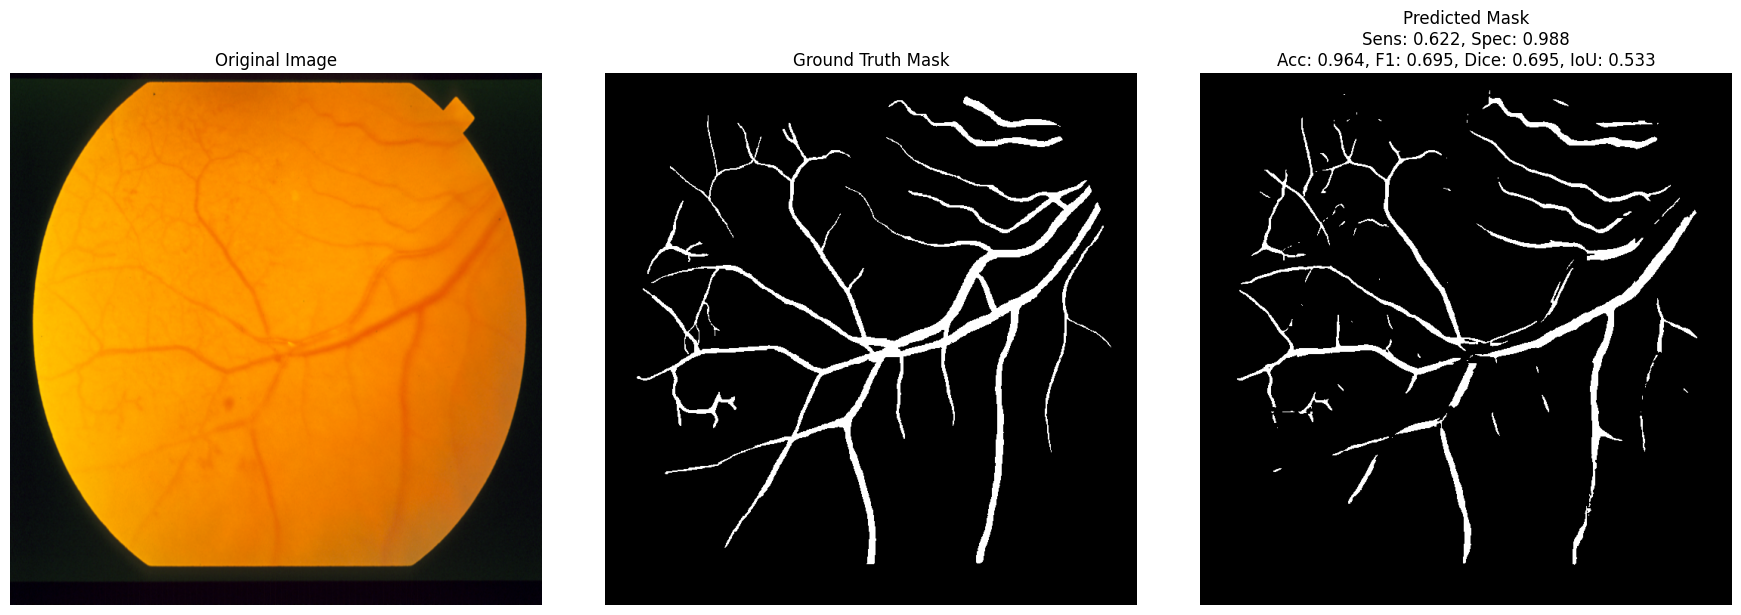

Saved original image: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet original image\original_image_5.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet predicted_mask\predicted_mask_5.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet_ground_truth_mask\ground_truth_mask_5.png
Metrics for Image 5 written to CSV.
All test image metrics saved to C:\Users\AUSTCSE4090\Desktop\STARE\csv files\sharpunet__metrics.csv


In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

# Directories to save predictions, ground truth masks, and original images
PREDICTIONS_DIR = r'C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet predicted_mask'
GROUND_TRUTH_DIR = r'C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet_ground_truth_mask'
ORIGINAL_IMAGES_DIR = r'C:\Users\AUSTCSE4090\Desktop\STARE\mask\sharpunet original image'
os.makedirs(PREDICTIONS_DIR, exist_ok=True)
os.makedirs(GROUND_TRUTH_DIR, exist_ok=True)
os.makedirs(ORIGINAL_IMAGES_DIR, exist_ok=True)

# Constants
THRESHOLD = 0.5
RESIZE_SIZE = 704
CSV_FILE = r"C:\Users\AUSTCSE4090\Desktop\STARE\csv files\sharpunet__metrics.csv"

# Define the function to save predicted masks
def save_predicted_mask(pred_mask, idx):
    mask_bin = (pred_mask > THRESHOLD).astype(np.uint8) * 255  # Binarize
    save_path = os.path.join(PREDICTIONS_DIR, f"predicted_mask_{idx + 1}.png")
    cv2.imwrite(save_path, mask_bin)
    print(f"Saved predicted mask: {save_path}")

# Define the function to save ground truth masks
def save_ground_truth_mask(gt_mask, idx):
    mask_bin = (gt_mask * 255).astype(np.uint8)  # Ensure it is in 0-255 range
    save_path = os.path.join(GROUND_TRUTH_DIR, f"ground_truth_mask_{idx + 1}.png")
    cv2.imwrite(save_path, mask_bin)
    print(f"Saved ground truth mask: {save_path}")

# Define the function to save the original images
def save_original_image(img, idx):
    save_path = os.path.join(ORIGINAL_IMAGES_DIR, f"original_image_{idx + 1}.png")
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)  # Convert RGB to BGR for saving with OpenCV
    cv2.imwrite(save_path, img_bgr)
    print(f"Saved original image: {save_path}")

# Function to compute per-image metrics
def compute_metrics_per_image(y_true, y_pred):
    y_true = y_true.astype(np.uint8)
    y_pred = y_pred.astype(np.uint8)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    sensitivity = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    precision = TP / (TP + FP + 1e-6)
    f1_score = 2 * precision * sensitivity / (precision + sensitivity + 1e-6)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-6)
    iou = TP / (TP + FP + FN + 1e-6)

    return sensitivity, specificity, accuracy, f1_score, dice, iou

# Initialize CSV file and write header
def initialize_csv():
    with open(CSV_FILE, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Image_Index", "Sensitivity", "Specificity", "Accuracy", "F1_Score", "Dice", "IoU"])

# Write metrics to CSV
def write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou):
    with open(CSV_FILE, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([idx + 1, sens, spec, acc, f1, dice, iou])
    print(f"Metrics for Image {idx + 1} written to CSV.")

# Modify the visualization function to show original image, ground truth, and predicted mask
def visualize_metrics_and_save_prediction(model, img_path, mask_path, idx):
    # Predict mask for the image
    img, pred_mask = predict_full_image(model, img_path)  # Ensure this function is defined
    
    # Check if the prediction and image are correct
    if img is None or pred_mask is None:
        print(f"Prediction failed for image {img_path}")
        return

    # Read and preprocess the ground truth mask
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0
    
    # Apply thresholding to both ground truth and predicted masks to ensure they are binary
    gt_mask_bin = (gt_mask >= 0.5).astype(np.uint8)  # Ground truth as binary (0 or 1)
    pred_mask_bin = (pred_mask >= THRESHOLD).astype(np.uint8)  # Predicted mask as binary (0 or 1)
    
    # Compute metrics
    sens, spec, acc, f1, dice, iou = compute_metrics_per_image(gt_mask_bin, pred_mask_bin)
    
    # Print the metrics to verify if they are being calculated correctly
    print(f"Metrics for Image {idx + 1}: Sens: {sens:.3f}, Spec: {spec:.3f}, Acc: {acc:.3f}, F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}")

    # Plot the original image, ground truth, and predicted mask
    plt.figure(figsize=(18, 6))  # Increase the size to accommodate all 3 images
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    
    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask_bin, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_bin, cmap='gray')
    plt.title(f"Predicted Mask\nSens: {sens:.3f}, Spec: {spec:.3f}\n"
              f"Acc: {acc:.3f}, F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

    # Save the original image, predicted mask, and ground truth mask
    save_original_image(img, idx)
    save_predicted_mask(pred_mask, idx)
    save_ground_truth_mask(gt_mask, idx)

    # Write the metrics to the CSV file
    write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou)

# Initialize the CSV file with the header
initialize_csv()

# Example usage: 
for idx, (img_path, mask_path) in enumerate(zip(test_images, test_masks)):
    visualize_metrics_and_save_prediction(model, img_path, mask_path, idx)

print(f"All test image metrics saved to {CSV_FILE}")


In [11]:
import os

# Define the folder path to save the model
folder_path = r'C:\Users\AUSTCSE4090\Desktop\STARE\predictions\prediction'  # Update this path if needed
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Define the model save path
model_save_path = os.path.join(folder_path, 'attunet_model.h5')

# Save the model in H5 format
model.save(model_save_path)
print(f"Saved model to {model_save_path}")


Saved model to C:\Users\AUSTCSE4090\Desktop\STARE\predictions\prediction\attr2unet_model.h5


In [29]:
from tensorflow.keras import backend as K

# Clear any previous models and free memory
K.clear_session()
